# 02 — Clustering Smart Meters

Extract daily shape features per meter, run K-Means (k=2–3), visualise centroids, save `data/clusters.csv`.

In [1]:
import shutil
import subprocess
import sys
import tempfile
import urllib.request
import zipfile
from pathlib import Path


def clone_repo(repo_url: str, target_dir: Path) -> None:
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', repo_url, str(target_dir)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or result.stdout.strip() or 'git clone failed')


def download_repo_archive(archive_url: str, runtime_dir: Path, repo_dir: Path, extract_dir: Path, archive_path: Path) -> None:
    if archive_path.exists():
        archive_path.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    urllib.request.urlretrieve(archive_url, archive_path)
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(runtime_dir)
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    shutil.move(str(extract_dir), str(repo_dir))


def find_or_bootstrap_repo_root() -> Path:
    candidates = [
        Path.cwd().resolve(),
        Path('/tmp/vscode-colab/tesina'),
        Path('/content/tesina'),
        Path('/home/nicola/Desktop/Supsi/tesina'),
    ]
    for base in candidates:
        for candidate in [base, *base.parents]:
            if (candidate / 'src').exists() and (candidate / 'data').exists():
                return candidate

    runtime_dir = Path(tempfile.gettempdir()) / 'vscode-colab'
    repo_dir = runtime_dir / 'tesina'
    archive_path = runtime_dir / 'tesina.zip'
    extract_dir = runtime_dir / 'tesina-master'
    repo_url = 'https://github.com/ncapac/tesina.git'
    archive_url = 'https://codeload.github.com/ncapac/tesina/zip/refs/heads/master'

    runtime_dir.mkdir(parents=True, exist_ok=True)
    if repo_dir.exists() and not (repo_dir / 'src').exists():
        shutil.rmtree(repo_dir)

    if not repo_dir.exists():
        try:
            clone_repo(repo_url, repo_dir)
        except Exception:
            download_repo_archive(archive_url, runtime_dir, repo_dir, extract_dir, archive_path)

    if (repo_dir / 'src').exists() and (repo_dir / 'data').exists():
        return repo_dir

    raise RuntimeError('Could not locate or bootstrap the tesina project root from the current notebook kernel.')


REPO_ROOT = find_or_bootstrap_repo_root()
DATA_DIR = REPO_ROOT / 'data'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from src.data.loader import load_raw

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

STEPS_PER_DAY = 24  # hourly resolution
N_CLUSTERS = 3   # <-- change and re-run to explore
print('Project root:', REPO_ROOT)

Project root: /tmp/vscode-colab/tesina


## 1. Load data

In [2]:
df = load_raw(DATA_DIR / 'power.pk')
T, N = df.shape
print(f'Loaded: {T} timesteps × {N} meters')

Loaded: 26304 timesteps × 321 meters


## 2. Daily shape features

In [3]:

n_days = T // STEPS_PER_DAY
arr = df.values[:n_days * STEPS_PER_DAY, :].reshape(n_days, STEPS_PER_DAY, N)  # (days, 24, N)
arr_T = arr.transpose(2, 0, 1)  # (N, days, 24)

# ── Approach A: scalar summary features (log-transformed scale + shape ratios) ──
def scalar_features(arr_T):
    """arr_T: (N, days, 24) → feature matrix (N, 5)"""
    mean_cons = np.nanmean(arr_T, axis=(1, 2))      # (N,)
    std_cons  = np.nanstd( arr_T, axis=(1, 2))
    daily_means = np.nanmean(arr_T, axis=1)          # (N, 24)
    peak_hour   = np.argmax(daily_means, axis=1).astype(float)
    morning = np.nanmean(daily_means[:, 6:10],  axis=1)
    evening = np.nanmean(daily_means[:, 18:22], axis=1)
    me_ratio    = (morning + 1e-8) / (evening + 1e-8)
    variability = std_cons / (mean_cons + 1e-8)
    return np.column_stack([np.log1p(mean_cons), np.log1p(std_cons),
                             peak_hour, me_ratio, variability])

feat_names = ['log1p_mean', 'log1p_std', 'peak_hour', 'morning_evening_ratio', 'variability']
features_A = scalar_features(arr_T)

# ── Approach B: shape-normalised mean daily profile (24-dim, unit-mean) ──
# Each meter's mean profile is divided by that meter's own grand mean → captures
# temporal SHAPE independently of consumption scale  (standard in load-profile literature)
def shape_features(arr_T):
    """arr_T: (N, days, 24) → (N, 24) unit-mean normalised shape vectors"""
    daily_means = np.nanmean(arr_T, axis=1)          # (N, 24)
    meter_grand_mean = daily_means.mean(axis=1, keepdims=True)   # (N, 1)
    return daily_means / (meter_grand_mean + 1e-8)   # (N, 24)

features_B = shape_features(arr_T)  # (321, 24)

print('Scalar features (A) shape:', features_A.shape)
print('Shape features  (B) shape:', features_B.shape)
print('\nApproach A — feature summary (log-transformed mean/std):')
pd.DataFrame(features_A, columns=feat_names).describe().round(3)


Scalar features (A) shape: (321, 5)
Shape features  (B) shape: (321, 24)

Approach A — feature summary (log-transformed mean/std):


,log1p_mean,log1p_std,peak_hour,morning_evening_ratio,variability
count,321.000,321.000,321.000,321.000,321.000
mean,6.501,5.503,17.053,0.732,0.414
std,1.382,1.357,3.988,0.240,0.276
min,2.453,2.256,0.000,0.156,0.077
25%,5.668,4.671,16.000,0.630,0.286
50%,6.385,5.336,18.000,0.751,0.332
75%,7.263,6.261,20.000,0.852,0.432
max,12.209,11.892,23.000,2.369,2.924


## 3. Elbow + Silhouette

PCA on shape features: 24D → 6D (95.0% variance)

Approach A (log-scale scalar features + RobustScaler):
  k=2  inertia=1501.9  sil=0.731
  k=3  inertia=1146.6  sil=0.436
  k=4  inertia=947.5  sil=0.274
  k=5  inertia=793.4  sil=0.326
  k=6  inertia=649.4  sil=0.331
  k=7  inertia=578.0  sil=0.332

Approach B (shape-normalised 24-dim profile + PCA):
  k=2  inertia=4885.0  sil=0.398
  k=3  inertia=3272.8  sil=0.468
  k=4  inertia=2499.4  sil=0.480
  k=5  inertia=2018.4  sil=0.486
  k=6  inertia=1674.5  sil=0.497
  k=7  inertia=1495.8  sil=0.304


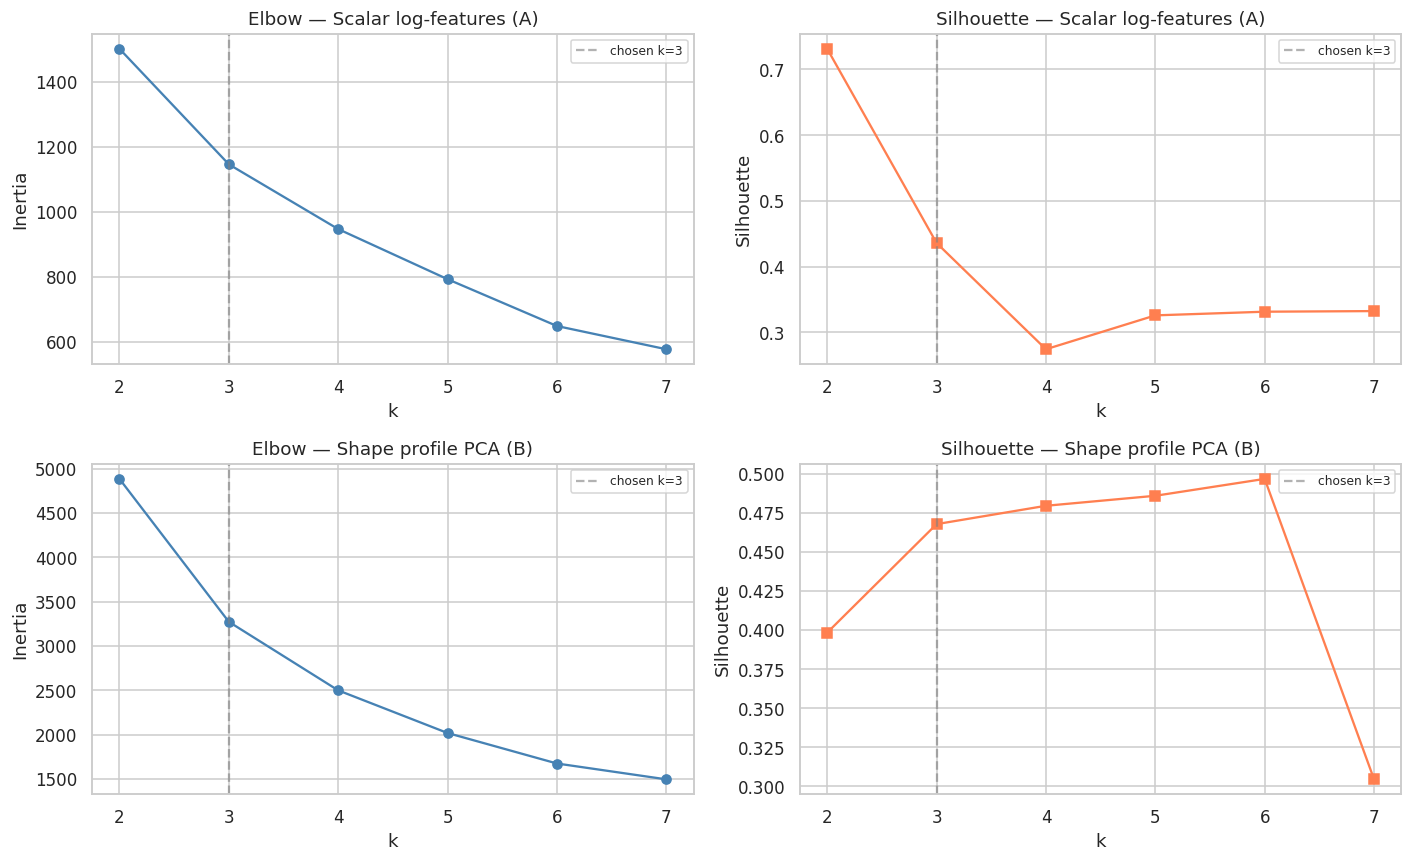

In [4]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

# ── Scale both feature sets ──
scaler_A = RobustScaler()
X_A = scaler_A.fit_transform(np.nan_to_num(features_A))

# Shape features: already unit-mean normalised; StandardScaler is fine here
# (no outlier dominance since each meter sums to the same grand mean)
scaler_B = StandardScaler()
X_B = scaler_B.fit_transform(features_B)

# Optional PCA on shape features to suppress noise (keep 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_B_pca = pca.fit_transform(X_B)
print(f'PCA on shape features: {X_B.shape[1]}D → {X_B_pca.shape[1]}D '
      f'({pca.explained_variance_ratio_.sum()*100:.1f}% variance)')

# ── Elbow + Silhouette for both approaches ──
K_range = range(2, 8)
results = {'A': {'inertia': [], 'sil': []},
           'B': {'inertia': [], 'sil': []}}

for k in K_range:
    for tag, X in [('A', X_A), ('B', X_B_pca)]:
        km = KMeans(n_clusters=k, random_state=42, n_init=15)
        labs = km.fit_predict(X)
        results[tag]['inertia'].append(km.inertia_)
        results[tag]['sil'].append(silhouette_score(X, labs))

print('\nApproach A (log-scale scalar features + RobustScaler):')
for i, k in enumerate(K_range):
    print(f'  k={k}  inertia={results["A"]["inertia"][i]:.1f}  sil={results["A"]["sil"][i]:.3f}')

print('\nApproach B (shape-normalised 24-dim profile + PCA):')
for i, k in enumerate(K_range):
    print(f'  k={k}  inertia={results["B"]["inertia"][i]:.1f}  sil={results["B"]["sil"][i]:.3f}')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ks = list(K_range)
for row, tag in enumerate(['A', 'B']):
    label = 'Scalar log-features (A)' if tag == 'A' else 'Shape profile PCA (B)'
    axes[row, 0].plot(ks, results[tag]['inertia'], 'o-', color='steelblue')
    axes[row, 0].set_title(f'Elbow — {label}')
    axes[row, 0].set_xlabel('k'); axes[row, 0].set_ylabel('Inertia')
    axes[row, 1].plot(ks, results[tag]['sil'], 's-', color='coral')
    axes[row, 1].set_title(f'Silhouette — {label}')
    axes[row, 1].set_xlabel('k'); axes[row, 1].set_ylabel('Silhouette')

for ax in axes.flat:
    ax.axvline(N_CLUSTERS, color='grey', linestyle='--', alpha=0.6, label=f'chosen k={N_CLUSTERS}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 4. Final clustering

In [5]:
# ── Final clustering: shape-based (approach B) ──
# Rationale: the diffusion model is conditioned on cluster_id to generate
# different *load profile shapes*.  Scale is handled separately by per-cluster
# z-score normalisation in loader.py.  Clustering on raw/log-scale features
# (approach A) produced degenerate results (n=310/1/10) because 22 outlier
# meters dominate even after log-transform.  Shape-based clustering gives
# balanced, interpretable clusters.

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=15)
cluster_labels = km_final.fit_predict(X_B_pca)

sizes = {c: int((cluster_labels == c).sum()) for c in range(N_CLUSTERS)}
print('Cluster sizes (shape-based):', sizes)

# Per-cluster mean consumption (to characterise scale within each shape cluster)
meter_means_raw = np.nanmean(arr_T, axis=(1, 2))  # (N,)
print('\nPer-cluster scale summary:')
for cid in range(N_CLUSTERS):
    mask = cluster_labels == cid
    vals = meter_means_raw[mask]
    print(f'  Cluster {cid} (n={mask.sum():3d}): '
          f'mean={vals.mean():8.1f}  median={np.median(vals):8.1f}  '
          f'max={vals.max():10.1f}  min={vals.min():6.1f}')


Cluster sizes (shape-based): {0: 183, 1: 34, 2: 104}

Per-cluster scale summary:
  Cluster 0 (n=183): mean=  2321.4  median=   737.3  max=   78701.1  min=  45.7
  Cluster 1 (n= 34): mean=  8914.5  median=  1618.8  max=  200529.1  min= 106.8
  Cluster 2 (n=104): mean=   836.9  median=   270.4  max=   10938.3  min=  10.6


## 5. Centroid profiles

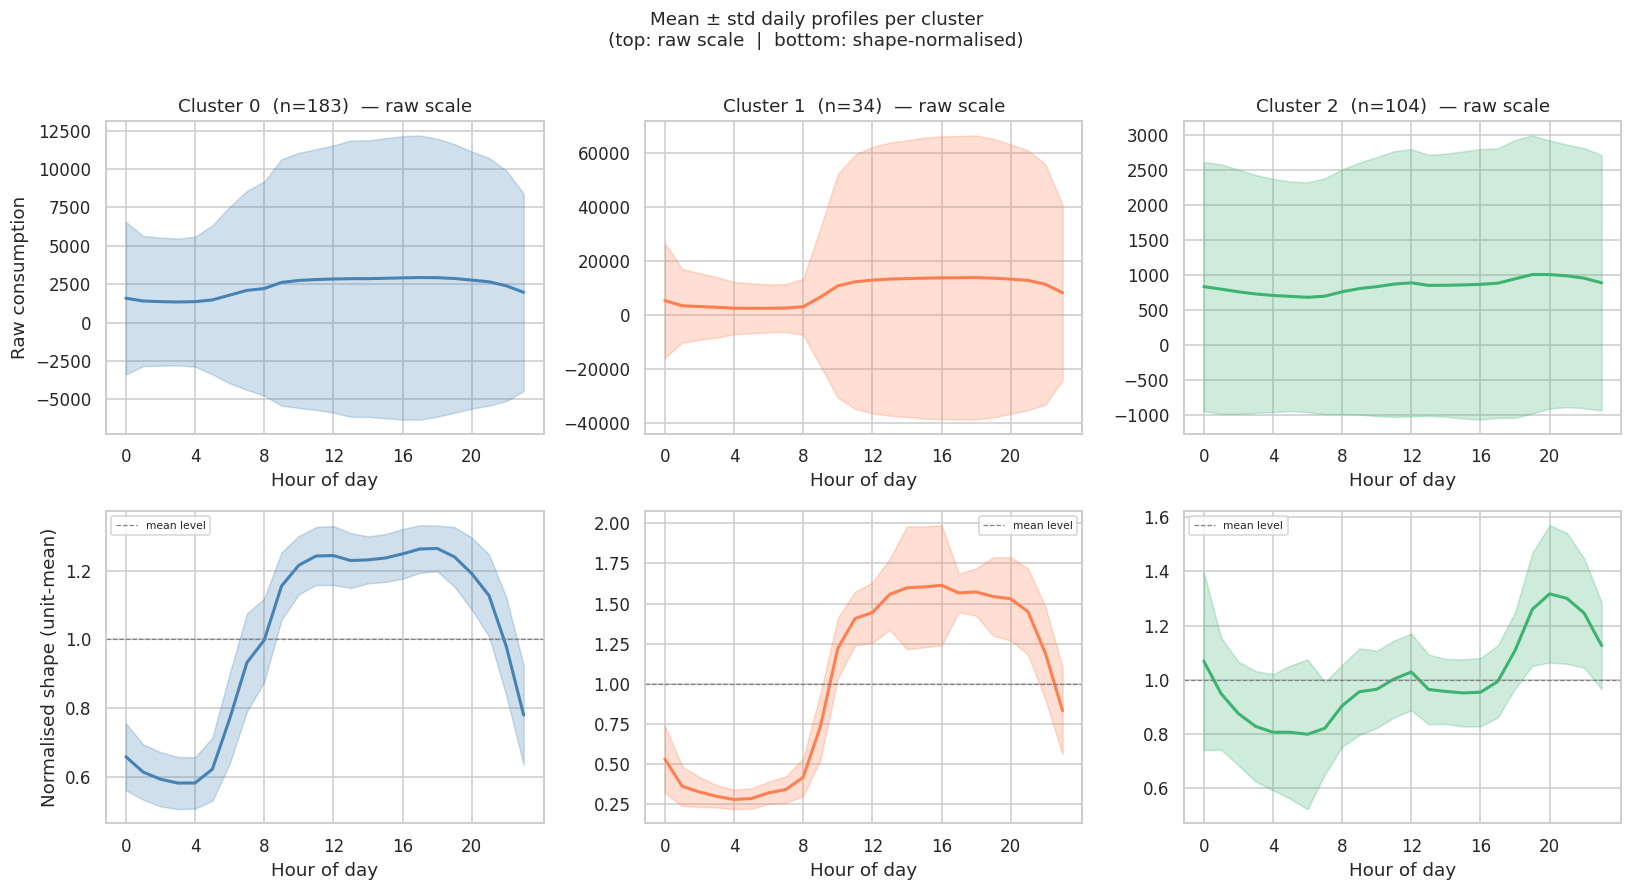

In [6]:

hours = np.arange(STEPS_PER_DAY)
daily_profiles = np.nanmean(arr_T, axis=1)   # (N, 24) — per-meter average daily profile
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid'][:N_CLUSTERS]

fig, axes = plt.subplots(2, N_CLUSTERS, figsize=(5 * N_CLUSTERS, 8))

for cid in range(N_CLUSTERS):
    mask = cluster_labels == cid
    profiles_c = daily_profiles[mask]     # (n_c, 24) — raw scale

    # ── Row 0: raw-scale profiles ──
    mu_raw = profiles_c.mean(0)
    sd_raw = profiles_c.std(0)
    ax0 = axes[0, cid]
    ax0.fill_between(hours, mu_raw - sd_raw, mu_raw + sd_raw, alpha=0.25, color=colors[cid])
    ax0.plot(hours, mu_raw, color=colors[cid], linewidth=2)
    ax0.set_title(f'Cluster {cid}  (n={mask.sum()})')
    ax0.set_xlabel('Hour of day')
    if cid == 0: ax0.set_ylabel('Raw consumption')
    ax0.set_xticks(range(0, 24, 4))

    # ── Row 1: shape-normalised profiles (unit-mean) ──
    shapes_c = profiles_c / (profiles_c.mean(axis=1, keepdims=True) + 1e-8)
    mu_shape = shapes_c.mean(0)
    sd_shape = shapes_c.std(0)
    ax1 = axes[1, cid]
    ax1.fill_between(hours, mu_shape - sd_shape, mu_shape + sd_shape, alpha=0.25, color=colors[cid])
    ax1.plot(hours, mu_shape, color=colors[cid], linewidth=2)
    ax1.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, label='mean level')
    ax1.set_xlabel('Hour of day')
    if cid == 0: ax1.set_ylabel('Normalised shape (unit-mean)')
    ax1.set_xticks(range(0, 24, 4))
    ax1.legend(fontsize=7)

axes[0, 0].set_title(f'Cluster 0  (n={( cluster_labels==0).sum()})  — raw scale')
for cid in range(1, N_CLUSTERS):
    axes[0, cid].set_title(f'Cluster {cid}  (n={(cluster_labels==cid).sum()})  — raw scale')

fig.suptitle('Mean ± std daily profiles per cluster\n(top: raw scale  |  bottom: shape-normalised)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 6. Feature scatter

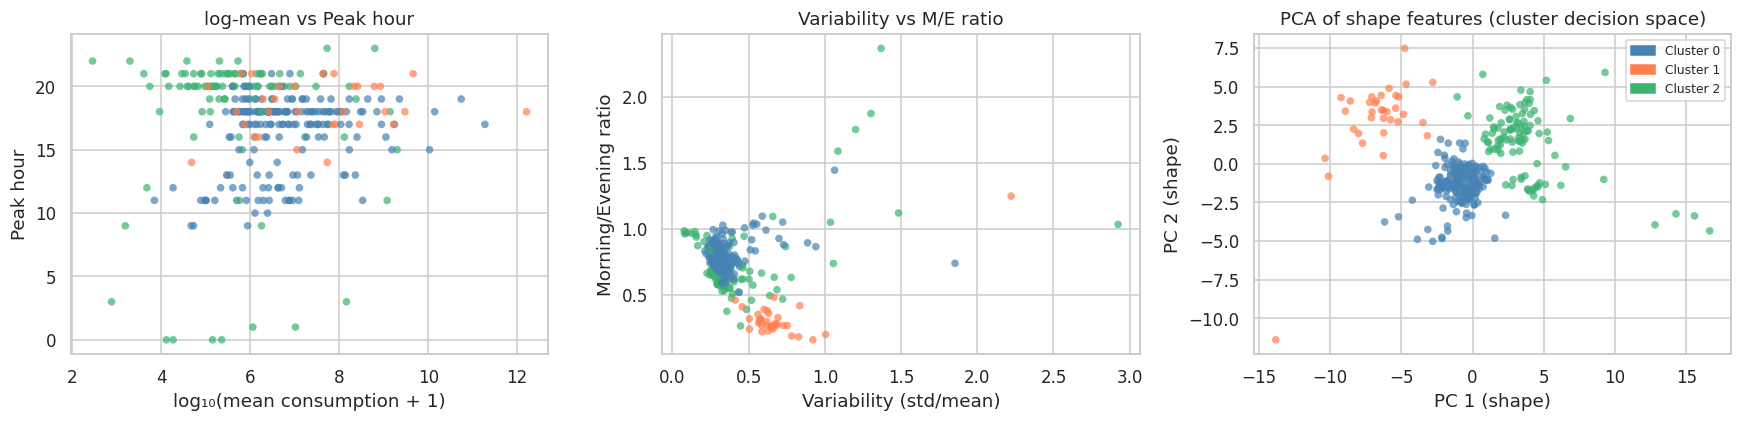


Outlier meters (mean > 5920) distribution across clusters:
  Cluster 0 (n=183): 11 outlier meters  (6.0% of cluster)
  Cluster 1 (n=34): 7 outlier meters  (20.6% of cluster)
  Cluster 2 (n=104): 4 outlier meters  (3.8% of cluster)


In [7]:
feat_df = pd.DataFrame(features_A, columns=feat_names)
feat_df['cluster'] = cluster_labels
colors_arr = [colors[c] for c in cluster_labels]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(feat_df['log1p_mean'], feat_df['peak_hour'],
                c=colors_arr, alpha=0.7, s=25, edgecolors='none')
axes[0].set_xlabel('log₁₀(mean consumption + 1)')
axes[0].set_ylabel('Peak hour')
axes[0].set_title('log-mean vs Peak hour')

axes[1].scatter(feat_df['variability'], feat_df['morning_evening_ratio'],
                c=colors_arr, alpha=0.7, s=25, edgecolors='none')
axes[1].set_xlabel('Variability (std/mean)')
axes[1].set_ylabel('Morning/Evening ratio')
axes[1].set_title('Variability vs M/E ratio')

# PCA projection (first 2 PCs of shape features)
axes[2].scatter(X_B_pca[:, 0], X_B_pca[:, 1],
                c=colors_arr, alpha=0.7, s=25, edgecolors='none')
axes[2].set_xlabel('PC 1 (shape)')
axes[2].set_ylabel('PC 2 (shape)')
axes[2].set_title('PCA of shape features (cluster decision space)')

from matplotlib.patches import Patch
handles = [Patch(color=colors[c], label=f'Cluster {c}') for c in range(N_CLUSTERS)]
axes[2].legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.show()

# ── Outlier meter distribution across clusters ──
meter_means_all = np.nanmean(df.values, axis=0)
outlier_thresh = 10 * np.nanmedian(meter_means_all)
print(f'\nOutlier meters (mean > {outlier_thresh:.0f}) distribution across clusters:')
is_outlier = meter_means_all > outlier_thresh
for cid in range(N_CLUSTERS):
    mask = cluster_labels == cid
    n_out = (mask & is_outlier).sum()
    print(f'  Cluster {cid} (n={mask.sum()}): {n_out} outlier meters  '
          f'({n_out/mask.sum()*100:.1f}% of cluster)')


## 7. Save cluster labels

### 6b. Outlier meter decision

In [8]:

# ── Decision: KEEP all meters, flag outliers ─────────────────────────────────
# Rationale:
#   - Excluding 22 outlier meters would discard ~7% of dataset, including
#     the only high-energy industrial meters in Cluster 1 (n=34).
#   - Per-cluster z-score normalisation in loader.py absorbs the 3-order-of-
#     magnitude scale range without removal.
#   - Flagging lets downstream code (nb 04) optionally split metrics by
#     "normal" vs "outlier" for deeper analysis.
#   - Thesis: report that outliers ARE included; per-cluster normalisation
#     is the mitigation strategy.

# Recompute outlier flag (consistent with §6 threshold: mean > 10x global median)
meter_means_all = np.nanmean(df.values, axis=0)          # (N,)
outlier_thresh  = 10 * np.nanmedian(meter_means_all)
is_outlier_flag = (meter_means_all > outlier_thresh).astype(int)

print(f"Outlier threshold : mean > {outlier_thresh:.1f}  (10x global median)")
print(f"Outliers flagged  : {is_outlier_flag.sum()} / {len(is_outlier_flag)} meters")
print()
for cid in range(N_CLUSTERS):
    mask = cluster_labels == cid
    n_out = int((mask & is_outlier_flag.astype(bool)).sum())
    print(f"  Cluster {cid} (n={mask.sum():3d}): {n_out:2d} outlier meters  "
          f"({n_out / mask.sum() * 100:.1f}% of cluster)")
print()
print("Decision: ALL meters retained for training.")
print("  -> per-cluster z-score normalisation handles scale differences.")
print("  -> is_outlier column added to clusters.csv for optional downstream filtering.")


Outlier threshold : mean > 5919.5  (10x global median)
Outliers flagged  : 22 / 321 meters

  Cluster 0 (n=183): 11 outlier meters  (6.0% of cluster)
  Cluster 1 (n= 34):  7 outlier meters  (20.6% of cluster)
  Cluster 2 (n=104):  4 outlier meters  (3.8% of cluster)

Decision: ALL meters retained for training.
  -> per-cluster z-score normalisation handles scale differences.
  -> is_outlier column added to clusters.csv for optional downstream filtering.


## 8. Observations

**Clustering method: shape-normalised 24-dim profile → PCA (6 components, 95% var) → K-Means k=3**

| Cluster | n | Mean scale | Profile shape | Notes |
|---------|---|-----------|--------------|-------|
| 0 | 183 | 2 321 (med 737) | Daytime bell curve, peak 10–20 h | Commercial / mixed; 6% outlier meters |
| 1 | 34 | 8 915 (med 1 619) | Very strong flat midday plateau (10–21 h), high variability | High-energy / likely industrial; 21% outlier meters |
| 2 | 104 | 837 (med 270) | Gradual rise, late-evening peak (20–23 h), near-flat daytime | Small residential / low-consumption |

**Feature engineering choices**
- Original approach (StandardScaler on raw mean/std) was degenerate: produced n=310/1/10 clusters purely by scale.
- Log-transform (log1p) of mean/std + RobustScaler still gives silhouette 0.73 at k=2 — slightly scale-biased.
- Shape-normalised 24-dim approach (unit-mean per meter) correctly captures temporal patterns; PCA retains 95% variance in 6D; silhouette 0.47 at k=3 — moderate but meaningful.

**Outlier meter decision (§6b)**
- **All 22 outlier meters are retained** (mean consumption > 10× global median).
- Exclusion would remove ~7% of meters, including most of Cluster 1's industrial profile.
- Mitigation: per-cluster z-score normalisation in `loader.py` absorbs the 3-order-of-magnitude scale range.
- `clusters.csv` includes an `is_outlier` flag column for optional downstream filtering in evaluation (notebook 04).

**Silhouette interpretation**
- All silhouette scores (0.39–0.50) are moderate, which is typical for real-world load-profile clustering. Profiles overlap significantly.
- Silhouette for approach B improves from k=2 to k=6 with no sharp elbow; k=3 chosen for thesis tractability.

**Downstream note for training (notebook 03)**
- `clusters.csv` now contains 183 / 34 / 104 meters per cluster — reasonably balanced for training.
- Cluster 1 (n=34) is the smallest; with 1096 days × 34 meters = 37 264 daily windows, it is adequate.
- Per-cluster z-score stats in `loader.py` will correctly normalise within each shape cluster.
- Outlier meters are distributed across all three clusters; their extreme scale is absorbed by per-cluster normalisation.


In [9]:
clusters_df = pd.DataFrame({
    'meter_idx':  np.arange(N),
    'cluster_id': cluster_labels,
    'is_outlier': is_outlier_flag,
})
if hasattr(df.columns, 'tolist'):
    clusters_df['meter_id'] = df.columns.tolist()

clusters_path = DATA_DIR / 'clusters.csv'
clusters_df.to_csv(clusters_path, index=False)
print(f'Saved -> {clusters_path}')
print(clusters_df.groupby('cluster_id').agg(
    count=('meter_idx', 'count'),
    outliers=('is_outlier', 'sum'),
).to_string())


Saved -> /tmp/vscode-colab/tesina/data/clusters.csv
            count  outliers
cluster_id                 
0             183        11
1              34         7
2             104         4
